In [ ]:
#################################################################################################################

import os, sys

#################################################################################################################

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')
results_dir = os.path.join(project_path, 'results', 'experiment_6')
results_path = os.path.join(results_dir, 'results_exp_6.pkl')

#################################################################################################################

sys.path.append(project_path)
from config.config_experiment_6 import N_REALIZATIONS
from src.utils.experiments_exploration_utils import process_experiment_6_results, plot_experiment_6_results

#################################################################################################################

In [3]:
df, df_avg = process_experiment_6_results(results_path=results_path)

✅ Archivo cargado correctamente.
📊 Número de realizaciones (sampling seeds) capturadas: 10


In [4]:
df

sampling_seed,model_name,time,adj_accuracy,ARI
i64,str,f64,f64,f64
6863,"""FastKmedoidsGGower-robust_maha…",11.786794,0.9238,0.810668
6863,"""FoldFastKmedoidsGGower-robust_…",9.38162,0.921743,0.806057
35084,"""FastKmedoidsGGower-robust_maha…",11.712309,0.9222,0.807034
35084,"""FoldFastKmedoidsGGower-robust_…",9.251428,0.921171,0.804575
11427,"""FastKmedoidsGGower-robust_maha…",12.214632,0.922143,0.807045
…,…,…,…,…
49692,"""FoldFastKmedoidsGGower-robust_…",9.383993,0.922143,0.806705
70281,"""FastKmedoidsGGower-robust_maha…",11.800212,0.921829,0.806129
70281,"""FoldFastKmedoidsGGower-robust_…",9.355347,0.923629,0.810408


In [5]:
df_avg

model_name,mean_acc,std_acc,mean_ari,std_ari,mean_time,std_time
str,f64,f64,f64,f64,f64,f64
"""FastKmedoidsGGower-robust_maha…",0.922637,0.00151,0.808121,0.003382,11.908131,0.369052
"""FoldFastKmedoidsGGower-robust_…",0.921303,0.001687,0.805156,0.003665,9.426243,0.311572


In [31]:
ref_acc = df_avg['mean_acc'].median()
std_acc = df_avg['std_acc'].median()
epsilon_acc =  std_acc + 0.05
ylim_acc = (ref_acc - epsilon_acc, ref_acc + epsilon_acc)

ref_ari = df_avg['mean_ari'].median()
std_ari = df_avg['std_ari'].median()
epsilon_ari = std_ari + 0.05
ylim_ari = (ref_ari - epsilon_ari, ref_ari + epsilon_ari)

ref_time = df_avg['mean_time'].median()
std_time = df_avg['std_time'].median()
epsilon_time = std_time + 5
ylim_time = (ref_time - epsilon_time, ref_time + epsilon_time)

print(f'ylim_acc: {ylim_acc}')
print(f'ylim_ari: {ylim_ari}')
print(f'ylim_time: {ylim_time}')

ylim_acc: (0.8703714454589079, 0.973568554541092)
ylim_ari: (0.7531149790245465, 0.8601615431286324)
ylim_time: (5.32687512136385, 16.007498758068827)


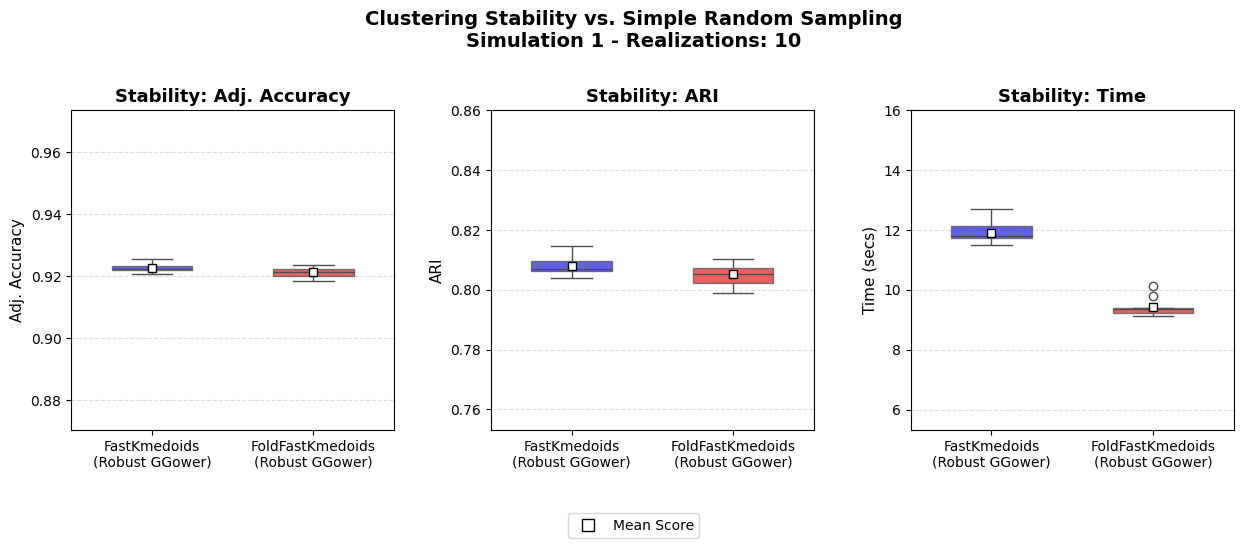

In [32]:
plot_filename = f'plot_results_exp_6.png'
save_path = os.path.join(results_dir, plot_filename)

plot_experiment_6_results(
    df=df, 
    num_realizations=N_REALIZATIONS, 
    save_path=save_path,
    ylim_acc=ylim_acc,
    ylim_ari=ylim_ari,
    ylim_time=ylim_time, 
)